In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_percentage_error

## Practica 3: Emulator for luminosity distance

#### 2 Train a Neural Network for the luminosity distance

In [2]:
# Generate a function that calculate the luminosity distance for a given redshift, a H0 and a Ωm value.



# constants for units 
c = 299792.458 # speed of light in km/s
H0 = 70.0 # Hubble constant in km/s/Mpc
Omega_m = 0.3 # Matter density parameter
Omega_L = 0.7 # Dark energy density parameter


def E(z):
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

def luminosity_distance(z, H0, Omega_m):
    # Calculate the luminosity distance using the formula:
    # d_L = (c / H0) * (1 + z) * integral from 0 to z of dz' / E(z')
    integral, _ = quad(lambda z_prime: 1 / E(z_prime), 0, z)
    
    # Calculate the luminosity distance
    d_L = (c / H0) * (1 + z) * integral
    return d_L


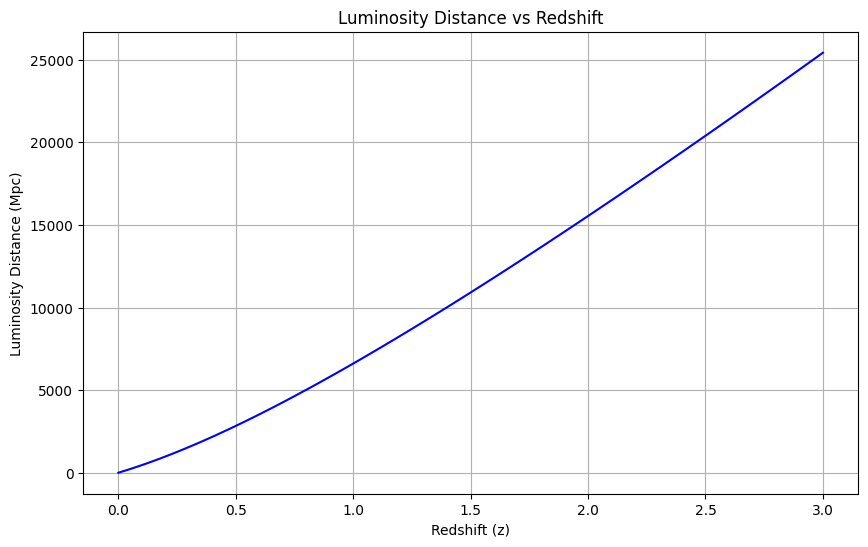

In [3]:
z_values = np.linspace(0.001, 3, 100)  

d_L_values = [luminosity_distance(z, H0, Omega_m) for z in z_values]

plt.figure(figsize=(10, 6))
plt.plot(z_values, d_L_values, label='Luminosity Distance', color='blue')
plt.xlabel('Redshift (z)')
plt.ylabel('Luminosity Distance (Mpc)')
plt.title('Luminosity Distance vs Redshift')
plt.grid()
plt.show()

In [4]:
'''
Create trainning and validation samples that covers z ∈ (0, 3), H0 ∈ (60, 85), and Ωm ∈ (0.1, 0.5). This
time, we do not give you the size of the samples, you have to define it.
'''

z_train = np.random.uniform(0, 3, 800)  
H0_train = np.random.uniform(60, 85, 800)
Omega_m_train = np.random.uniform(0.1, 0.5, 800)


z_val = np.random.uniform(0, 3, 200)
H0_val = np.random.uniform(60, 85, 200)
Omega_m_val = np.random.uniform(0.1, 0.5, 200)




In [5]:
'''
Create a Neural Netwrok that allows to reproduce, with less than 3% for 95% of the best cases of the
validation set, error on the luminosity distance over the full space.
'''



# Define the model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(3,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32)


/opt/anaconda3/envs/sbi_39/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'X_train' is not defined